# Week 11: DBSCAN and hierarchical clustering

This notebook applies both Week 11 clustering methods to Wisconsin breast-cancer measurements and Brazil cancer-registry records. DBSCAN is the primary analysis because it can identify dense groups and label isolated observations as noise. Hierarchical agglomerative clustering is included as the companion method required by the Milestone 2 rubric.

The target is excluded from all clustering fits and is used afterward only for descriptive outcome profiles.

## Milestone 2 questions

- Does density-based clustering find meaningful groups or substantial noise?
- How do DBSCAN's eps and min_samples parameters change the result?
- How does hierarchical clustering compare when the number of clusters is specified?
- Do discovered groups differ in the known diagnosis/outcome?

These address the clarifier's depth expectations: show parameter selection, explain model behavior, test sensitivity, and interpret meaningful or unexpected results.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from src.load_data import load_wisconsin, load_brazil

RANDOM_STATE = 42
BRAZIL_DBSCAN_ROWS = 30_000
BRAZIL_HIERARCHICAL_ROWS = 5_000
K_VALUES = range(2, 9)
FIGURE_DIR = Path("outputs/figures/milestone2")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load and inspect both datasets

Wisconsin is small enough to analyze directly. DBSCAN and hierarchical clustering require neighborhood or distance calculations, so Brazil uses a documented reproducible sample. This keeps the workflow computationally practical while making the sampling choice explicit.

In [2]:
wisconsin_df, wisconsin_target = load_wisconsin()
brazil_df, brazil_target = load_brazil(sample_size=BRAZIL_DBSCAN_ROWS, random_state=RANDOM_STATE)

dataset_overview = pd.DataFrame({
    "dataset": ["Wisconsin", "Brazil"],
    "rows_used": [len(wisconsin_df), len(brazil_df)],
    "predictors": [wisconsin_df.shape[1] - 1, brazil_df.shape[1] - 1],
    "missing_predictor_values": [
        wisconsin_df.drop(columns=wisconsin_target).isna().sum().sum(),
        brazil_df.drop(columns=brazil_target).isna().sum().sum(),
    ],
    "known_outcome_rate": [
        wisconsin_df[wisconsin_target].mean(),
        brazil_df[brazil_target].mean(),
    ],
})
display(dataset_overview)
print(f"Brazil sample size: {len(brazil_df):,}; random_state={RANDOM_STATE}")

,dataset,rows_used,predictors,missing_predictor_values,known_outcome_rate
0,Wisconsin,569,30,0,0.372583
1,Brazil,30000,39,0,0.071400


Brazil sample size: 30,000; random_state=42


## 2. Preprocessing for distance-based clustering

Both methods depend on distances. I remove the target and diagnosis-year field, median-impute numeric predictor missingness, and standardize predictors so large-unit or large-code variables do not dominate. The target is never supplied to DBSCAN or hierarchical clustering, preventing target leakage.

In [3]:
def prepare_for_clustering(df, target, scaled=True, columns=None):
    X = df.drop(columns=[target], errors="ignore").copy()
    X = X.drop(columns=["diagnosis_year"], errors="ignore")
    if columns is not None:
        X = X[columns]
    X = X.select_dtypes(include=[np.number])
    X = SimpleImputer(strategy="median").fit_transform(X)
    return StandardScaler().fit_transform(X) if scaled else X

X_w = prepare_for_clustering(wisconsin_df, wisconsin_target)
X_b = prepare_for_clustering(brazil_df, brazil_target)
print("Wisconsin matrix:", X_w.shape)
print("Brazil matrix:", X_b.shape)

Wisconsin matrix: (569, 30)
Brazil matrix: (30000, 39)


## 3. DBSCAN parameter exploration

DBSCAN has two central parameters. eps is the neighborhood radius: increasing it makes more observations neighbors and usually reduces noise. min_samples is the minimum number of observations required for a dense core point: increasing it makes the density requirement stricter.

For each configuration I record the number of clusters, the fraction labeled noise, and the silhouette score on non-noise observations. A silhouette score is not meaningful when every point is noise or when only one non-noise cluster remains.

In [4]:
def dbscan_grid(X, dataset, eps_values, min_samples_values):
    rows, models = [], {}
    for min_samples in min_samples_values:
        for eps in eps_values:
            model = DBSCAN(eps=eps, min_samples=min_samples, metric="euclidean", n_jobs=-1)
            labels = model.fit_predict(X)
            non_noise = labels != -1
            cluster_count = len(set(labels[non_noise]))
            noise_fraction = 1 - non_noise.mean()
            if cluster_count >= 2 and non_noise.sum() > 2:
                score = silhouette_score(
                    X[non_noise], labels[non_noise],
                    sample_size=min(5_000, int(non_noise.sum())),
                    random_state=RANDOM_STATE,
                )
            else:
                score = np.nan
            key = (min_samples, eps)
            rows.append({
                "dataset": dataset,
                "eps": eps,
                "min_samples": min_samples,
                "clusters_excluding_noise": cluster_count,
                "noise_fraction": noise_fraction,
                "silhouette_non_noise": score,
            })
            models[key] = model
    return pd.DataFrame(rows), models

eps_values = [0.3, 0.5, 0.7, 1.0, 1.3, 1.7, 2.2]
min_samples_values = [5, 10, 20]
dbscan_w, dbscan_w_models = dbscan_grid(X_w, "Wisconsin", eps_values, min_samples_values)
dbscan_b, dbscan_b_models = dbscan_grid(X_b, "Brazil", eps_values, min_samples_values)
dbscan_results = pd.concat([dbscan_w, dbscan_b], ignore_index=True)
display(dbscan_results.round(3))

,dataset,eps,min_samples,clusters_excluding_noise,noise_fraction,silhouette_non_noise
0,Wisconsin,0.3,5,0,1.000,NaN
1,Wisconsin,0.5,5,0,1.000,NaN
2,Wisconsin,0.7,5,0,1.000,NaN
3,Wisconsin,1.0,5,0,1.000,NaN
4,Wisconsin,1.3,5,1,0.991,NaN
5,Wisconsin,1.7,5,1,0.858,NaN
6,Wisconsin,2.2,5,4,0.548,0.166
7,Wisconsin,0.3,10,0,1.000,NaN
8,Wisconsin,0.5,10,0,1.000,NaN
9,Wisconsin,0.7,10,0,1.000,NaN


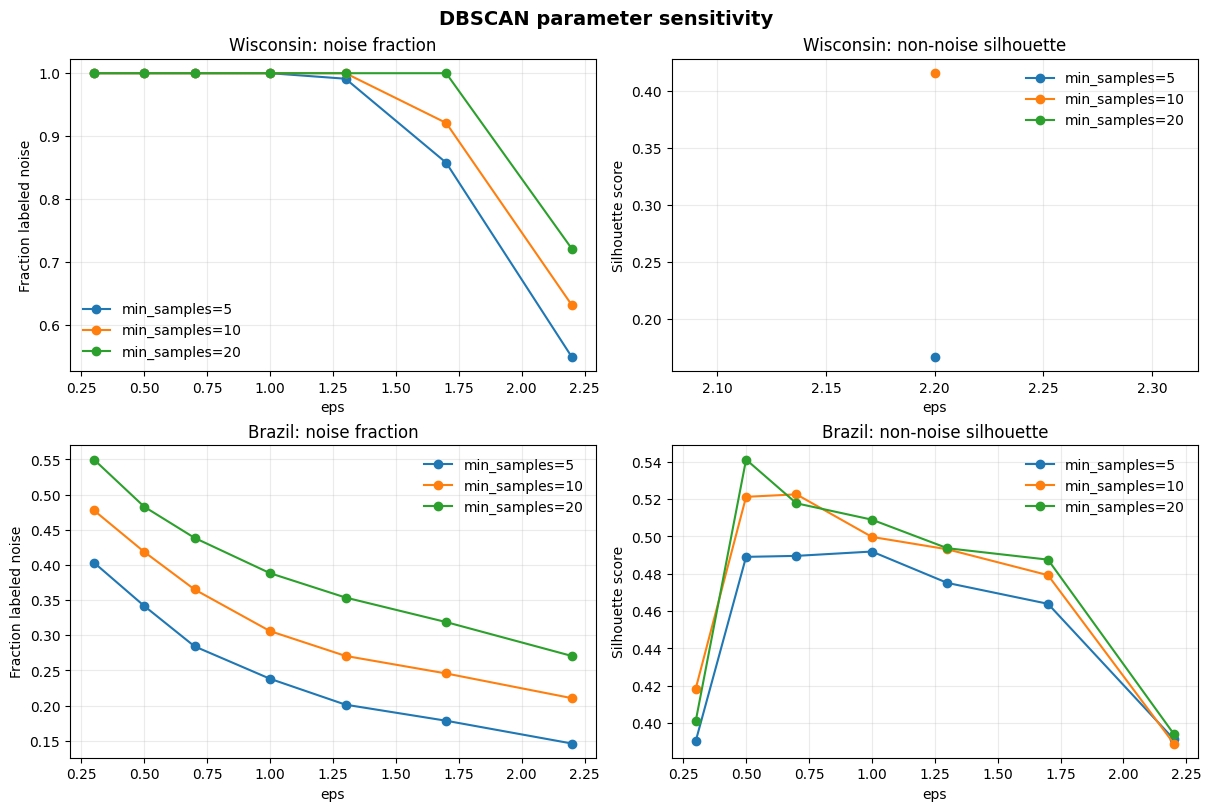

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for row, dataset in enumerate(["Wisconsin", "Brazil"]):
    data = dbscan_results[dbscan_results.dataset == dataset]
    for min_samples in min_samples_values:
        subset = data[data.min_samples == min_samples]
        axes[row, 0].plot(subset.eps, subset.noise_fraction, marker="o", label=f"min_samples={min_samples}")
        axes[row, 1].plot(subset.eps, subset.silhouette_non_noise, marker="o", label=f"min_samples={min_samples}")
    axes[row, 0].set(title=f"{dataset}: noise fraction", xlabel="eps", ylabel="Fraction labeled noise")
    axes[row, 1].set(title=f"{dataset}: non-noise silhouette", xlabel="eps", ylabel="Silhouette score")
    for ax in axes[row]:
        ax.grid(alpha=.25)
        ax.legend(frameon=False)
fig.suptitle("DBSCAN parameter sensitivity", fontsize=14, fontweight="bold")
fig.savefig(FIGURE_DIR / "week11_dbscan_parameter_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

### DBSCAN selection rule

The preferred configuration is the highest non-noise silhouette among configurations with at least two clusters and no more than 80 percent noise. The noise cap prevents choosing a trivial solution that calls almost every observation an outlier. This is an exploratory rule, not a universal DBSCAN standard; the tradeoff should be explained with the project's context.

In [6]:
def select_dbscan(results):
    eligible = results[
        (results["clusters_excluding_noise"] >= 2)
        & (results["noise_fraction"] <= .80)
        & results["silhouette_non_noise"].notna()
    ]
    if eligible.empty:
        eligible = results[results["silhouette_non_noise"].notna()]
    return eligible.loc[eligible["silhouette_non_noise"].idxmax()]

best_dbscan_w = select_dbscan(dbscan_w)
best_dbscan_b = select_dbscan(dbscan_b)
display(pd.DataFrame([best_dbscan_w, best_dbscan_b]).round(3))

,dataset,eps,min_samples,clusters_excluding_noise,noise_fraction,silhouette_non_noise
13,Wisconsin,2.2,10,2,0.631,0.416
15,Brazil,0.5,20,63,0.483,0.541


## 4. Final DBSCAN profiles

DBSCAN is deterministic for fixed data and parameters, so its main robustness question is parameter sensitivity rather than random initialization. Noise is retained as its own descriptive category and is not silently discarded.

In [7]:
def fit_selected_dbscan(X, selected):
    model = DBSCAN(
        eps=float(selected.eps),
        min_samples=int(selected.min_samples),
        metric="euclidean",
        n_jobs=-1,
    )
    return model, model.fit_predict(X)

model_w, labels_w = fit_selected_dbscan(X_w, best_dbscan_w)
model_b, labels_b = fit_selected_dbscan(X_b, best_dbscan_b)

def dbscan_profile(labels, y, dataset, selected):
    data = pd.DataFrame({"cluster": labels, "outcome": np.asarray(y)})
    result = data.groupby("cluster", as_index=False).agg(
        n=("outcome", "size"), outcome_rate=("outcome", "mean")
    )
    result.insert(0, "dataset", dataset)
    result.insert(1, "eps", float(selected.eps))
    result.insert(2, "min_samples", int(selected.min_samples))
    return result

dbscan_profiles = pd.concat([
    dbscan_profile(labels_w, wisconsin_df[wisconsin_target], "Wisconsin", best_dbscan_w),
    dbscan_profile(labels_b, brazil_df[brazil_target], "Brazil", best_dbscan_b),
], ignore_index=True)
display(dbscan_profiles.assign(outcome_rate=lambda d: d.outcome_rate.round(3)))
print("Noise fraction:", {"Wisconsin": round((labels_w == -1).mean(), 3),
                           "Brazil": round((labels_b == -1).mean(), 3)})

,dataset,eps,min_samples,cluster,n,outcome_rate
0,Wisconsin,2.2,10,-1,359,0.540
1,Wisconsin,2.2,10,0,199,0.035
2,Wisconsin,2.2,10,1,11,1.000
3,Brazil,0.5,20,-1,14480,0.137
4,Brazil,0.5,20,0,2850,0.000
...,...,...,...,...,...,...
62,Brazil,0.5,20,58,37,0.000
63,Brazil,0.5,20,59,22,0.000
64,Brazil,0.5,20,60,20,0.000
65,Brazil,0.5,20,61,28,0.000


Noise fraction: {'Wisconsin': np.float64(0.631), 'Brazil': np.float64(0.483)}


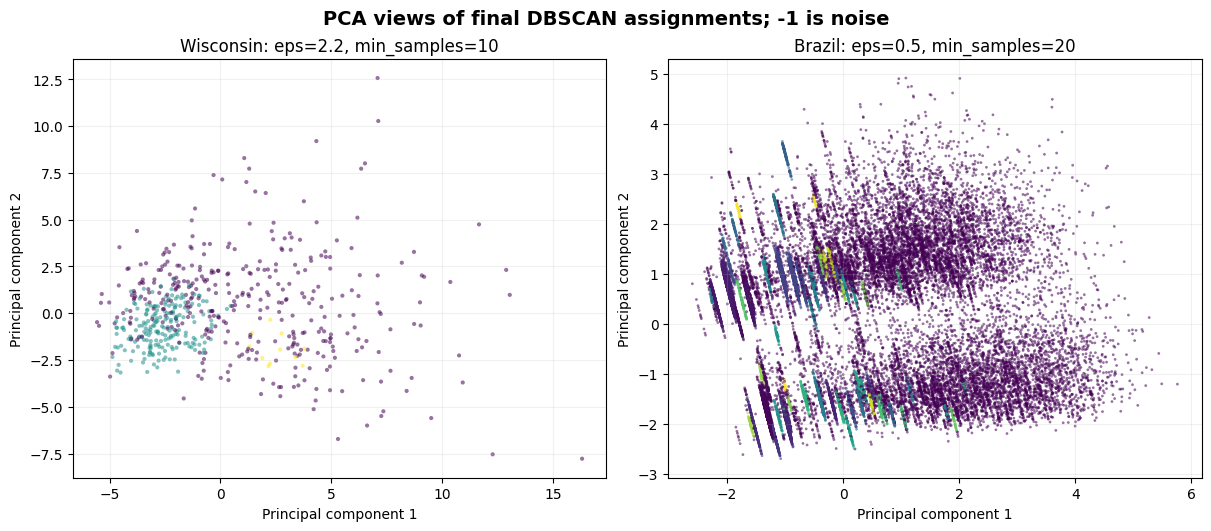

In [8]:
pca_w = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_w)
pca_b = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_b)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), constrained_layout=True)
for ax, coordinates, labels, dataset, selected in [
    (axes[0], pca_w, labels_w, "Wisconsin", best_dbscan_w),
    (axes[1], pca_b, labels_b, "Brazil", best_dbscan_b),
]:
    ax.scatter(
        coordinates[:, 0], coordinates[:, 1], c=labels, cmap="viridis",
        s=9 if dataset == "Wisconsin" else 4, alpha=.55, linewidths=0,
    )
    ax.set(
        title=f"{dataset}: eps={selected.eps}, min_samples={int(selected.min_samples)}",
        xlabel="Principal component 1", ylabel="Principal component 2",
    )
    ax.grid(alpha=.18)
fig.suptitle("PCA views of final DBSCAN assignments; -1 is noise", fontsize=14, fontweight="bold")
fig.savefig(FIGURE_DIR / "week11_dbscan_pca_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Hierarchical agglomerative clustering

Agglomerative clustering starts with each observation as its own group and repeatedly merges the closest groups. Unlike DBSCAN, it does not identify noise on its own and requires a requested number of clusters. I compare Ward and average linkage over k=2 through k=8. Ward linkage minimizes within-cluster variance; average linkage provides a sensitivity comparison.

In [9]:
def hierarchical_grid(X, dataset, row_indices=None):
    X_fit = X if row_indices is None else X[row_indices]
    rows, models = [], {}
    for linkage in ["ward", "average"]:
        for k in K_VALUES:
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
            labels = model.fit_predict(X_fit)
            rows.append({
                "dataset": dataset,
                "linkage": linkage,
                "k": k,
                "silhouette": silhouette_score(X_fit, labels),
            })
            models[(linkage, k)] = model
    return pd.DataFrame(rows), models

b_hier_rows = np.random.default_rng(RANDOM_STATE).choice(
    len(X_b), size=min(BRAZIL_HIERARCHICAL_ROWS, len(X_b)), replace=False
)
hier_w, hier_w_models = hierarchical_grid(X_w, "Wisconsin")
hier_b, hier_b_models = hierarchical_grid(X_b, "Brazil", row_indices=b_hier_rows)
hierarchical_results = pd.concat([hier_w, hier_b], ignore_index=True)
display(hierarchical_results.round(3))

,dataset,linkage,k,silhouette
0,Wisconsin,ward,2,0.339
1,Wisconsin,ward,3,0.330
2,Wisconsin,ward,4,0.298
3,Wisconsin,ward,5,0.243
4,Wisconsin,ward,6,0.120
5,Wisconsin,ward,7,0.124
6,Wisconsin,ward,8,0.096
7,Wisconsin,average,2,0.634
8,Wisconsin,average,3,0.585
9,Wisconsin,average,4,0.554


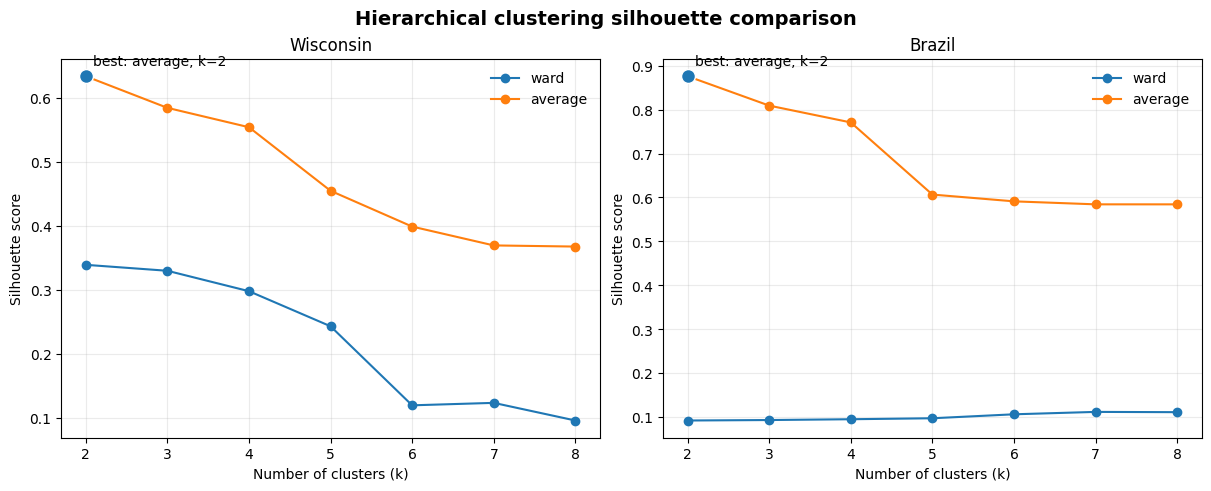

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
for ax, dataset in zip(axes, ["Wisconsin", "Brazil"]):
    data = hierarchical_results[hierarchical_results.dataset == dataset]
    for linkage in ["ward", "average"]:
        subset = data[data.linkage == linkage]
        ax.plot(subset.k, subset.silhouette, marker="o", label=linkage)
    best = data.loc[data.silhouette.idxmax()]
    ax.scatter(best.k, best.silhouette, s=100, edgecolor="white", zorder=4)
    ax.annotate(f"best: {best.linkage}, k={int(best.k)}", (best.k, best.silhouette), xytext=(5, 8), textcoords="offset points")
    ax.set(title=dataset, xlabel="Number of clusters (k)", ylabel="Silhouette score")
    ax.set_xticks(list(K_VALUES))
    ax.grid(alpha=.25)
    ax.legend(frameon=False)
fig.suptitle("Hierarchical clustering silhouette comparison", fontsize=14, fontweight="bold")
fig.savefig(FIGURE_DIR / "week11_hierarchical_silhouette.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Compare outcome profiles across methods

The outcome is added back only after clustering. These profiles are descriptive associations, not predictive metrics and not evidence that the clusters cause the outcome. For Brazil, the hierarchical result is evaluated on the documented 5,000-row sample used for pairwise clustering.

In [11]:
best_hier_w = hier_w.loc[hier_w.silhouette.idxmax()]
best_hier_b = hier_b.loc[hier_b.silhouette.idxmax()]
hier_labels_w = hier_w_models[(best_hier_w.linkage, int(best_hier_w.k))].labels_
hier_labels_b = hier_b_models[(best_hier_b.linkage, int(best_hier_b.k))].labels_

def hierarchical_profile(labels, y, dataset, selected):
    data = pd.DataFrame({"cluster": labels, "outcome": np.asarray(y)})
    result = data.groupby("cluster", as_index=False).agg(
        n=("outcome", "size"), outcome_rate=("outcome", "mean")
    )
    result.insert(0, "dataset", dataset)
    result.insert(1, "linkage", selected.linkage)
    result.insert(2, "k", int(selected.k))
    return result

hier_profiles = pd.concat([
    hierarchical_profile(hier_labels_w, wisconsin_df.iloc[:len(hier_labels_w)][wisconsin_target], "Wisconsin", best_hier_w),
    hierarchical_profile(hier_labels_b, brazil_df.iloc[b_hier_rows][brazil_target], "Brazil", best_hier_b),
], ignore_index=True)
display(hier_profiles.assign(outcome_rate=lambda d: d.outcome_rate.round(3)))

,dataset,linkage,k,cluster,n,outcome_rate
0,Wisconsin,average,2,0,566,0.369
1,Wisconsin,average,2,1,3,1.000
2,Brazil,average,2,0,4998,0.070
3,Brazil,average,2,1,2,0.000


In [12]:
comparison = pd.DataFrame([
    {
        "dataset": "Wisconsin", "method": "DBSCAN",
        "clusters_or_noise": len(set(labels_w)) - (-1 in labels_w),
        "noise_fraction": (labels_w == -1).mean(),
        "best_internal_score": best_dbscan_w.silhouette_non_noise,
    },
    {
        "dataset": "Brazil", "method": "DBSCAN",
        "clusters_or_noise": len(set(labels_b)) - (-1 in labels_b),
        "noise_fraction": (labels_b == -1).mean(),
        "best_internal_score": best_dbscan_b.silhouette_non_noise,
    },
    {
        "dataset": "Wisconsin", "method": "Hierarchical",
        "clusters_or_noise": int(best_hier_w.k), "noise_fraction": 0,
        "best_internal_score": best_hier_w.silhouette,
    },
    {
        "dataset": "Brazil", "method": "Hierarchical",
        "clusters_or_noise": int(best_hier_b.k), "noise_fraction": 0,
        "best_internal_score": best_hier_b.silhouette,
    },
])
display(comparison.round(3))

,dataset,method,clusters_or_noise,noise_fraction,best_internal_score
0,Wisconsin,DBSCAN,2,0.631,0.416
1,Brazil,DBSCAN,63,0.483,0.541
2,Wisconsin,Hierarchical,2,0.000,0.634
3,Brazil,Hierarchical,2,0.000,0.876


## Milestone 2 interpretation draft

DBSCAN and hierarchical clustering answer different questions. DBSCAN asks whether observations form sufficiently dense regions under a chosen distance scale and allows isolated observations to remain noise. Hierarchical clustering always produces a partition at the requested k, so it is useful when a complete segmentation is desired but can hide the fact that the data may not have naturally separated groups.

The strongest evidence is the combination of parameter sensitivity, silhouette score, noise fraction, PCA display, and outcome profiles. A high silhouette with extreme noise is not automatically a good solution, and a low silhouette is evidence that the chosen representation does not support well-separated groups. Brazil requires extra caution because the registry data are heterogeneous, partly sparse, and analyzed on a sample for computational reasons.

For Milestone 2 breadth, report both DBSCAN and hierarchical results for both datasets, including parameter choices, internal metrics, noise handling, and limitations. For depth, DBSCAN is the stronger candidate: explain eps and min_samples geometrically, show how the noise fraction changes, and discuss whether the selected clusters are meaningful or artifacts of scaling and representation. Outcome differences should be framed as hypothesis-generating associations rather than causal or validated clinical strata.

## AI-use note for the eventual appendix

AI assistance was used to help organize the Week 11 notebook workflow, identify Milestone 2 rubric requirements, draft analysis-cell language, and suggest diagnostic comparisons. All data loading, model fitting, metrics, plots, and interpretations should be reviewed and verified by the student before submission.